# QualCheck: BERT-Based Rubric-Guided Semantic Evaluation Pipeline for Code Reports

**Camarines Sur Polytechnic Colleges – College of Computer Studies**

This notebook implements the full QualCheck training and evaluation pipeline as described in the Methodology (Chapter 3), specifically customized for evaluating **Code Reports**.

**Dataset Context:** 
A synthetic dataset of 10,000 code report entries encompassing programming assignments and documentation evaluations based on:
- Conceptual understanding
- Explanation clarity
- Methodological correctness
- Technical coherence

**Implementation Pipeline:**
- Phase 1 – Data Collection & Preprocessing
- Phase 2 – BERT Encoding & Fine-Tuning (BERT-base-uncased)
- Phase 3 – Cosine Similarity Scoring 
- Phase 4 – Threshold Calibration and Relevance Classification (Grid Search)
- Phase 5 – System Evaluation + Baseline Comparisons + Statistical Tests

> **Dataset CSV columns expected:** `question`, `evaluation_criterion`, `rubric_descriptor`, `quality_label`, `response`  
> **Labels:** `Fully Relevant`, `Partially Relevant`, `Irrelevant`

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
# Install required packages
%pip install transformers torch safetensors scikit-learn pandas numpy nltk spacy scipy statsmodels matplotlib seaborn tqdm -q
!python -m spacy download en_core_web_sm -q

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
print('✓ All packages installed')

Note: you may need to restart the kernel to use updated packages.
/home/marcdextersael/miniconda3/bin/python: No module named spacy
✓ All packages installed


In [3]:
import os, json, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (BertTokenizer, BertModel,
                          get_linear_schedule_with_warmup)
from safetensors.torch import save_file, load_file
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, balanced_accuracy_score, f1_score,
                              precision_score, recall_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as tfidf_cos

from scipy.stats import pearsonr, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import spacy

print('✓ Imports complete')


✓ Imports complete


In [15]:
# ─────────────────────────────────────────────────────────────────
# CONFIGURATION  ← adjust paths and column names to match your CSV
# ─────────────────────────────────────────────────────────────────
class Config:
    # ── Data ──────────────────────────────────────────────────────
    DATA_PATH          = "datasets/codereports/codereport_dataset_FIXED_v3.csv"   # ← v3: Partially Relevant responses regenerated from the REAL Fully
                                                                                #   Relevant answer to each question (truncated/gapped/sparsified via
                                                                                #   4 randomized strategies) — removes a 0.997-balanced-accuracy
                                                                                #   content/phrasing tell the old templated Partial text had, even
                                                                                #   with length fully controlled. See regenerate_partial_responses.py.
                                                                                #   NOTE: response-length leak on Partially Relevant is NOT fixed at
                                                                                #   the CSV level (see Phase 1.6 audit) — it is mitigated at train
                                                                                #   time instead via LENGTH_AUGMENT below, for BOTH the Siamese
                                                                                #   model and the Phase 3.6 cross-encoder.

    # Column names (case-sensitive – must match CSV headers exactly)
    # Matches the merged qualcheck_dataset.csv schema:
    # question, response_text, criterion, rubric_descriptor, label
    COL_QUESTION       = "question"
    COL_CRITERION      = "criterion"          # set None if absent
    COL_RUBRIC         = "rubric_descriptor"
    COL_LABEL          = "label"
    COL_RESPONSE       = "response_text"
    COL_OUTPUT_TYPE    = "output_type"        # set None if absent

    # ── Labels ────────────────────────────────────────────────────
    LABEL2ID   = {"Fully Relevant": 2, "Partially Relevant": 1, "Irrelevant": 0}
    ID2LABEL   = {2: "Fully Relevant",  1: "Partially Relevant", 0: "Irrelevant"}
    NUM_LABELS = 3

    # ── BERT ──────────────────────────────────────────────────────
    BERT_MODEL = "bert-base-uncased"

    # Code report responses run much longer than short-answer/essay text
    # (multi-section walkthroughs with code + explanation). A tokenizer
    # check on batch 84 (bert-base-uncased, real WordPiece counts) showed:
    #   - response_text   : mean ~221 tokens, max ~596, 33.3% exceed 256
    #   - question+rubric  : mean ~165 tokens, max ~211 (comfortably < 256)
    # So the two sides get separate limits instead of one shared MAX_LEN —
    # no point paying attention-cost on the short side just to fix the long one.
    MAX_LEN_PR = 256          # question + rubric pair — fits comfortably
    MAX_LEN_R  = 512          # response — covers ~94% of responses vs ~67% at 256
                               # (512 is also BERT's absolute position-embedding ceiling)

    # ── Training ──────────────────────────────────────────────────
    BATCH_SIZE    = 16        # reduce to 8 on low-VRAM GPU (MAX_LEN_R=512 uses more memory)
    LR            = 2e-5
    MAX_EPOCHS    = 5
    PATIENCE      = 3         # early stopping
    WARMUP_RATIO  = 0.1
    DROPOUT       = 0.3

    # ── Length-decorrelation augmentation ────────────────────────────
    # Fixes the response-length leak on Partially Relevant (see Phase 1.6):
    # at train time, a fraction of Fully Relevant / Irrelevant responses are
    # randomly truncated into Partial's OWN CRITERION's observed length range
    # (criteria run at different natural lengths, so this must be done per
    # criterion — a global pool under-corrects some criteria). Never touches
    # the CSV; re-randomizes every epoch; applied to BOTH the Siamese
    # QualCheckDataset and the Phase 3.6 QualCheckCrossDataset so neither
    # architecture can exploit the shortcut. val/test are never augmented so
    # evaluation reflects the real (still length-imbalanced) distribution.
    LENGTH_AUGMENT_ENABLED = True
    LENGTH_AUGMENT_RATIO   = 0.7     # 0.5 wasn't enough for every criterion — see Phase 1.6

    # ── Split ─────────────────────────────────────────────────────
    TRAIN_RATIO   = 0.70
    VAL_RATIO     = 0.15
    TEST_RATIO    = 0.15
    SEED          = 42

    # ── Threshold calibration ─────────────────────────────────────
    THRESH_STEP   = 0.01

    # ── Paths ─────────────────────────────────────────────────────
    # Weights are stored as .safetensors (no pickle → no arbitrary code
    # execution risk on load, and faster to read than torch.save/.pt).
    OUTPUT_DIR       = "codereport_bert"
    BEST_CKPT        = "codereport_bert/best_model.safetensors"
    FINAL_MODEL      = "codereport_bert/qualcheck_final.safetensors"
    FINAL_META       = "codereport_bert/qualcheck_final_meta.json"   # thresholds + config (non-tensor)

    # ── Device ───────────────────────────────────────────────────
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import os
os.makedirs("codereport_bert", exist_ok=True)

cfg = Config()

# Global seeding for reproducibility (SEED already drove the data split/
# augmentation above; this extends it to model init, dropout, and shuffling)
random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)
torch.cuda.manual_seed_all(cfg.SEED)

print(f"Device: {cfg.DEVICE}")


Device: cuda


## Phase 1 – Data Loading & Exploration

In [5]:
df = pd.read_csv(cfg.DATA_PATH)
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}\n")

# ── Basic validation ──────────────────────────────────────────────
required = [cfg.COL_QUESTION, cfg.COL_RUBRIC, cfg.COL_LABEL, cfg.COL_RESPONSE]
missing  = [c for c in required if c not in df.columns]
assert not missing, f"Missing columns: {missing}"

# ── Label check ───────────────────────────────────────────────────
unknown = set(df[cfg.COL_LABEL].unique()) - set(cfg.LABEL2ID.keys())
if unknown:
    print(f"⚠ Unknown labels found (will be dropped): {unknown}")
    df = df[df[cfg.COL_LABEL].isin(cfg.LABEL2ID)]

df["label_id"] = df[cfg.COL_LABEL].map(cfg.LABEL2ID)

print("Label distribution:")
print(df[cfg.COL_LABEL].value_counts().to_string())

print("\nSample entry:")
print(df[[cfg.COL_QUESTION, cfg.COL_RUBRIC, cfg.COL_RESPONSE, cfg.COL_LABEL]].iloc[0].to_string())


Shape   : (10668, 5)
Columns : ['question', 'response_text', 'criterion', 'rubric_descriptor', 'label']

Label distribution:
label
Fully Relevant        3556
Partially Relevant    3556
Irrelevant            3556

Sample entry:
question             A billing system needs to convert the integer ...
rubric_descriptor    Check for correct CS terminology - are algorit...
response_text        TECHNICAL OVERVIEW: ROMAN NUMERAL CONVERSION\r...
label                                                   Fully Relevant


## Preprocessing – NLTK + spaCy

In [6]:
class TextPreprocessor:
    """Light preprocessing that preserves semantic content for BERT."""

    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words("english"))
        try:
            self.nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
        except Exception:
            self.nlp = None

    def clean_for_bert(self, text: str) -> str:
        """Minimal clean – keep casing and punctuation for BERT."""
        if pd.isna(text):
            return ""
        return str(text).strip()

    def deep_clean(self, text: str) -> str:
        """Full pipeline: lower → NLTK tokenise → remove stops → spaCy lemmatise.

        Per Chapter 3 Phase 1, preprocessing combines NLTK (tokenization,
        lowercasing, stopword removal) with spaCy (lemmatization).
        """
        if pd.isna(text):
            return ""
        text     = str(text).lower()
        tokens   = nltk.word_tokenize(text)
        filtered = [t for t in tokens if t.isalnum() and t not in self.stop_words]
        if self.nlp is not None:
            doc = self.nlp(" ".join(filtered))
            return " ".join(tok.lemma_ for tok in doc if tok.lemma_.strip())
        # Fallback to NLTK lemmatizer if spaCy failed to load
        return " ".join(self.lemmatizer.lemmatize(t) for t in filtered)

prep = TextPreprocessor()

# For BERT encoding – minimal cleaning
df["clean_question"]  = df[cfg.COL_QUESTION].apply(prep.clean_for_bert)
df["clean_rubric"]    = df[cfg.COL_RUBRIC].apply(prep.clean_for_bert)
df["clean_response"]  = df[cfg.COL_RESPONSE].apply(prep.clean_for_bert)

# Combine criterion + rubric → full rubric string sent to BERT
if cfg.COL_CRITERION and cfg.COL_CRITERION in df.columns:
    df["full_rubric"] = (df[cfg.COL_CRITERION].apply(prep.clean_for_bert)
                          + ". " + df["clean_rubric"])
else:
    df["full_rubric"] = df["clean_rubric"]

# Deep-cleaned text for TF-IDF baseline
df["tfidf_question"] = df[cfg.COL_QUESTION].apply(prep.deep_clean)
df["tfidf_rubric"]   = df["full_rubric"].apply(prep.deep_clean)
df["tfidf_response"] = df[cfg.COL_RESPONSE].apply(prep.deep_clean)

print(f"✓ Preprocessing complete  –  {len(df)} rows")
print("\nExample preprocessed question:")
print(df["clean_question"].iloc[0])


✓ Preprocessing complete  –  10668 rows

Example preprocessed question:
A billing system needs to convert the integer 1994 into a Roman numeral string and also parse the Roman numeral "MCMXCIV" back into its integer value. Implement both directions using a greedy symbol-value mapping table ordered from largest to smallest, trace the greedy subtraction steps for the integer-to-Roman direction and the left-to-right scan with subtractive-pair detection for the Roman-to-integer direction, report both final results, and explain why the six subtractive notation pairs (IV, IX, XL, XC, CD, CM) must be checked before their corresponding single symbols during the greedy scan to avoid misparsing.


## Phase 1.6 – Response-Length Confound Audit (diagnostic, no GPU required)

Partially Relevant responses in `codereport_dataset_FIXED.csv` are systematically shorter than Fully Relevant / Irrelevant ones, in every criterion, and the gap is criterion-specific (Technical Terminology ~1590 vs ~600 chars; Clarity & Cohesion ~2270 vs ~824). Any architecture that sees `response_text` — the two-tower Siamese model AND the Phase 3.6 cross-encoder — can exploit sequence length as a free shortcut for the Partial class instead of learning content. This almost certainly explains the earlier near-perfect classifier-head/cross-encoder scores.

Run this cell before training to confirm the leak. It only needs the CSV.


In [7]:
# ── Response-length confound audit ──────────────────────────────────
len_audit = df.copy()
len_audit["resp_len_chars"] = len_audit[cfg.COL_RESPONSE].astype(str).str.len()

print("Mean response length (characters) by criterion x label:")
print(len_audit.groupby([cfg.COL_CRITERION, cfg.COL_LABEL])["resp_len_chars"]
      .mean().unstack().to_string())

from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

def _leak_score(frame, len_col="resp_len_chars"):
    y = (frame[cfg.COL_LABEL] == "Partially Relevant").astype(int).values
    if y.sum() == 0 or y.sum() == len(y):
        return float("nan")
    clf = DecisionTreeClassifier(max_depth=1, random_state=cfg.SEED)
    return cross_val_score(clf, frame[[len_col]].values, y, cv=5, scoring="balanced_accuracy").mean()

print(f"\nGLOBAL leak balanced accuracy (length -> is Partial?): {_leak_score(len_audit):.4f}")
print("(0.50 = length carries no info about the label; near 1.0 pre-fix = severe leak)\n")

print("Per-criterion leak balanced accuracy:")
for crit, g in len_audit.groupby(cfg.COL_CRITERION):
    print(f"  {crit:<24} {_leak_score(g):.4f}")


Mean response length (characters) by criterion x label:
label                  Fully Relevant   Irrelevant  Partially Relevant
criterion                                                             
Algorithmic Logic         2017.051744  2017.512936         1339.091114
Clarity & Cohesion        2273.023622  2273.584927         1211.808774
Constraint Adherence      2137.703037  2138.427447         1318.631046
Technical Terminology     1590.725534  1590.998875          762.652418

GLOBAL leak balanced accuracy (length -> is Partial?): 0.7186
(0.50 = length carries no info about the label; near 1.0 pre-fix = severe leak)

Per-criterion leak balanced accuracy:
  Algorithmic Logic        0.6528
  Clarity & Cohesion       0.8023
  Constraint Adherence     0.7225
  Technical Terminology    0.8268


**Fix applied:** both `QualCheckDataset` (Phase 2) and `QualCheckCrossDataset` (Phase 3.6) now support `augment_length` — controlled by `LENGTH_AUGMENT_ENABLED`/`LENGTH_AUGMENT_RATIO` in Config. At train time only, a fraction of Fully Relevant / Irrelevant responses are randomly truncated into that SAME CRITERION's own Partial-length range, every epoch, without ever touching the CSV. The cell below proves this on the actual data before any GPU time is spent.


In [8]:
# ── Proof the augmentation removes the leak (pandas-only, no GPU) ──────
_aug_rng = np.random.default_rng(cfg.SEED)
_partial_lens_by_crit = {
    crit: g["resp_len_chars"].values
    for crit, g in len_audit.loc[len_audit[cfg.COL_LABEL] == "Partially Relevant"]
                              .groupby(cfg.COL_CRITERION)
}

def _simulate_augmented_len(row):
    if row[cfg.COL_LABEL] in ("Fully Relevant", "Irrelevant") and \
       _aug_rng.random() < cfg.LENGTH_AUGMENT_RATIO:
        pool = _partial_lens_by_crit.get(row[cfg.COL_CRITERION])
        if pool is not None and len(pool) > 0:
            target = int(_aug_rng.choice(pool))
            return min(row["resp_len_chars"], target)
    return row["resp_len_chars"]

len_audit["resp_len_chars_augmented"] = len_audit.apply(_simulate_augmented_len, axis=1)

print(f"GLOBAL   leak BEFORE: {_leak_score(len_audit,'resp_len_chars'):.4f}   "
      f"AFTER: {_leak_score(len_audit,'resp_len_chars_augmented'):.4f}")
print("\nPer-criterion leak AFTER augmentation (0.50 = fixed):")
worst = 0.0
for crit, g in len_audit.groupby(cfg.COL_CRITERION):
    score = _leak_score(g, "resp_len_chars_augmented")
    worst = max(worst, score)
    print(f"  {crit:<24} {score:.4f}")
print(f"\n{'✓ leak neutralized in every criterion' if worst < 0.60 else '⚠ still leaking — raise LENGTH_AUGMENT_RATIO'}")


GLOBAL   leak BEFORE: 0.7186   AFTER: 0.5000

Per-criterion leak AFTER augmentation (0.50 = fixed):
  Algorithmic Logic        0.5000
  Clarity & Cohesion       0.5000
  Constraint Adherence     0.5000
  Technical Terminology    0.5000

✓ leak neutralized in every criterion


In [9]:
# Group-aware 70 / 15 / 15 split, grouped by question.
#
# Each question in the code-report dataset is reused across 4 criteria x
# 3 labels (12 rows/question). A plain label-stratified split can place
# rows from the SAME question in both train and val/test, letting the
# model partially memorise question-specific surface patterns (variable
# names, problem framing) instead of learning generic relevance judgment
# — inflating val/test scores in a way that won't hold on genuinely
# unseen questions. GroupShuffleSplit keeps every row for a question in
# exactly one split.
from sklearn.model_selection import GroupShuffleSplit

question_col = cfg.COL_QUESTION

gss1 = GroupShuffleSplit(n_splits=1, test_size=(cfg.VAL_RATIO + cfg.TEST_RATIO),
                         random_state=cfg.SEED)
train_idx, temp_idx = next(gss1.split(df, groups=df[question_col]))
train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=cfg.SEED)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df[question_col]))
val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

N = len(df)
print(f"Train : {len(train_df):>6,}  ({len(train_df)/N*100:.1f}%)  |  unique questions: {train_df[question_col].nunique()}")
print(f"Val   : {len(val_df):>6,}  ({len(val_df)/N*100:.1f}%)  |  unique questions: {val_df[question_col].nunique()}")
print(f"Test  : {len(test_df):>6,}  ({len(test_df)/N*100:.1f}%)  |  unique questions: {test_df[question_col].nunique()}")

# ── Leakage guard ────────────────────────────────────────────────
train_q = set(train_df[question_col])
val_q   = set(val_df[question_col])
test_q  = set(test_df[question_col])
assert not (train_q & val_q),  "Leakage: question(s) appear in both train and val"
assert not (train_q & test_q), "Leakage: question(s) appear in both train and test"
assert not (val_q & test_q),   "Leakage: question(s) appear in both val and test"
print("\n✓ No question overlap across splits (0 shared questions confirmed)")

# Label distribution won't be perfectly stratified anymore (grouping
# takes priority over exact balance), but should stay broadly similar
# since each question contributes all 3 labels evenly. Worth eyeballing
# on every run, especially with small unique-question counts per batch.
for split, sdf in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n{split} label distribution:")
    print(sdf[cfg.COL_LABEL].value_counts().to_string())


Train :  7,464  (70.0%)  |  unique questions: 622
Val   :  1,596  (15.0%)  |  unique questions: 133
Test  :  1,608  (15.1%)  |  unique questions: 134

✓ No question overlap across splits (0 shared questions confirmed)

Train label distribution:
label
Fully Relevant        2488
Partially Relevant    2488
Irrelevant            2488

Val label distribution:
label
Fully Relevant        532
Partially Relevant    532
Irrelevant            532

Test label distribution:
label
Fully Relevant        536
Partially Relevant    536
Irrelevant            536


## Phase 1.5 – Synthetic Topic-Mismatch Negatives (train-only)


In [10]:
# ── Synthetic topic-mismatch negatives ──────────────────────────────
# Applied to train_df ONLY, and only AFTER the split above — augmenting
# before splitting would let a synthetic row and its "parent" row (same
# response_text, different question) land on opposite sides of train/val
# or train/test, which is its own kind of leakage on top of the
# question-identity leakage the split already guards against.
#
# Purpose: without this, the model can learn to associate well-written,
# well-structured code reports with "Fully/Partially Relevant" regardless
# of whether the report actually answers the question asked — i.e. it
# conflates writing/explanation quality with topical relevance. These
# synthetic rows pair a genuinely well-written response with a WRONG
# question, forcing "Irrelevant" as the label, so the model has to use
# topical alignment rather than just writing quality as a signal.
AUGMENT_ENABLED = True     # set False to train on original labels only
AUGMENT_RATIO   = 0.15     # synthetic rows added, as a fraction of train_df size
AUGMENT_SEED    = cfg.SEED

if AUGMENT_ENABLED:
    aug_rng = np.random.default_rng(AUGMENT_SEED)

    # Only draw from genuinely well-written reports — pairing an already-weak
    # report with the wrong question teaches nothing new, the model already
    # scores those low. We specifically want "good writing, wrong topic" rows.
    candidate_pool = train_df[train_df[cfg.COL_LABEL].isin(["Fully Relevant", "Partially Relevant"])]

    n_aug = int(len(train_df) * AUGMENT_RATIO)
    sampled = candidate_pool.sample(n=n_aug, random_state=AUGMENT_SEED,
                                    replace=(n_aug > len(candidate_pool)))

    # Mismatched questions are drawn from train_df only — never from val/test —
    # so no question identity introduced here crosses a split boundary.
    train_questions = train_df[cfg.COL_QUESTION].unique()

    aug_rows = []
    for _, row in sampled.iterrows():
        mismatched_q = row[cfg.COL_QUESTION]
        for _ in range(10):
            candidate_q = aug_rng.choice(train_questions)
            if candidate_q != row[cfg.COL_QUESTION]:
                mismatched_q = candidate_q
                break

        aug_rows.append({
            cfg.COL_QUESTION      : mismatched_q,                 # <- swapped
            cfg.COL_RESPONSE      : row[cfg.COL_RESPONSE],        # response untouched
            cfg.COL_CRITERION     : row[cfg.COL_CRITERION],
            cfg.COL_RUBRIC        : row[cfg.COL_RUBRIC],
            cfg.COL_LABEL         : "Irrelevant",
            "label_id"            : cfg.LABEL2ID["Irrelevant"],
            "clean_question"      : prep.clean_for_bert(mismatched_q),
            "clean_rubric"        : row["clean_rubric"],          # rubric/criterion unchanged
            "clean_response"      : row["clean_response"],
            "full_rubric"         : row["full_rubric"],           # depends on criterion, not question
            "tfidf_question"      : prep.deep_clean(mismatched_q),
            "tfidf_rubric"        : row["tfidf_rubric"],
            "tfidf_response"      : row["tfidf_response"],
            "_source"             : "synthetic_topic_mismatch",
        })

    aug_df = pd.DataFrame(aug_rows)

    # Any columns present in train_df but not explicitly set above (e.g. an
    # optional output_type column) get carried over as NaN — fill from the
    # source row where present so downstream code doesn't choke on gaps.
    for col in train_df.columns:
        if col not in aug_df.columns:
            aug_df[col] = sampled[col].values if col in sampled.columns else np.nan

    train_df = pd.concat([train_df, aug_df[train_df.columns]], ignore_index=True)

    print(f"Added {len(aug_df):,} synthetic topic-mismatch rows to train_df "
          f"({AUGMENT_RATIO:.0%} of pre-augmentation train size)")
    print(f"\nTrain label distribution AFTER augmentation:")
    print(train_df[cfg.COL_LABEL].value_counts().to_string())

    # Re-confirm train's question set (post-augmentation) is still fully
    # disjoint from val/test — augmentation only reuses questions already
    # in train_df, so this should always hold, but it's cheap to verify.
    post_aug_train_q = set(train_df[cfg.COL_QUESTION])
    assert not (post_aug_train_q & val_q),  "Augmentation introduced a question overlap with val"
    assert not (post_aug_train_q & test_q), "Augmentation introduced a question overlap with test"
    print("✓ Train questions (post-augmentation) still disjoint from val/test")
else:
    print("AUGMENT_ENABLED=False — training on original labels only.")


Added 1,119 synthetic topic-mismatch rows to train_df (15% of pre-augmentation train size)

Train label distribution AFTER augmentation:
label
Irrelevant            3607
Fully Relevant        2488
Partially Relevant    2488
✓ Train questions (post-augmentation) still disjoint from val/test


## Phase 2 – BERT Encoding & Fine-Tuning

### Dataset Class

In [11]:
class QualCheckDataset(Dataset):
    """
    Each sample encodes two segments:
      P  →  [CLS] question [SEP] rubric [SEP]     (max_len_pr)
      R  →  [CLS] response [SEP]                  (max_len_r, longer — code reports run long)

    Optional length-decorrelation augmentation (train split only, see Phase 1.6):
    Partially Relevant responses are systematically shorter than Fully Relevant /
    Irrelevant ones, per criterion, letting the model shortcut on response length
    instead of content. When augment_length=True, a fraction of Fully Relevant /
    Irrelevant samples are randomly truncated at __getitem__ time to a length
    drawn from that SAME CRITERION's Partial-class length distribution. This
    never touches the source dataframe/CSV — it re-randomizes on every access.
    """

    def __init__(self, dataframe, tokenizer, max_len_pr, max_len_r,
                 augment_length=False, augment_ratio=0.7,
                 partial_lengths_by_criterion=None,
                 label_col="label", response_col="response_text", criterion_col="criterion",
                 seed=42):
        self.df         = dataframe.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_len_pr = max_len_pr
        self.max_len_r  = max_len_r

        self.augment_length = augment_length
        self.augment_ratio  = augment_ratio
        self.label_col      = label_col
        self.response_col   = response_col
        self.criterion_col  = criterion_col
        self._rng            = np.random.default_rng(seed)

        if self.augment_length:
            if partial_lengths_by_criterion is None:
                partial_mask = self.df[self.label_col] == "Partially Relevant"
                partial_lengths_by_criterion = {
                    crit: g[self.response_col].astype(str).str.len().values
                    for crit, g in self.df.loc[partial_mask].groupby(self.criterion_col)
                }
            for crit, lens in partial_lengths_by_criterion.items():
                if len(lens) == 0:
                    raise ValueError(f"augment_length=True but no Partial-class lengths "
                                      f"available for criterion {crit!r}.")
            self._partial_lengths_by_criterion = partial_lengths_by_criterion

    def __len__(self):
        return len(self.df)

    def _encode(self, text_a, text_b, max_len):
        # transformers 5.x removed encode_plus() — the callable tokenizer()
        # interface is the replacement. text_b=None encodes a single segment.
        return self.tokenizer(
            text_a, text_b,
            add_special_tokens  = True,
            max_length          = max_len,
            padding             = "max_length",
            truncation          = True,
            return_attention_mask = True,
            return_tensors      = "pt"
        )

    def _maybe_truncate_response(self, response_text, label, criterion):
        if not self.augment_length:
            return response_text
        if label not in ("Fully Relevant", "Irrelevant"):
            return response_text
        if self._rng.random() >= self.augment_ratio:
            return response_text
        pool = self._partial_lengths_by_criterion.get(criterion)
        if pool is None or len(pool) == 0:
            return response_text
        target_len = int(self._rng.choice(pool))
        target_len = min(target_len, len(response_text))
        if target_len <= 0:
            return response_text
        return response_text[:target_len]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        response_text = self._maybe_truncate_response(
            row["clean_response"], row[self.label_col], row[self.criterion_col])

        pr = self._encode(row["clean_question"], row["full_rubric"], self.max_len_pr)
        r  = self._encode(response_text,          None,               self.max_len_r)

        return {
            "pr_ids"  : pr["input_ids"].squeeze(0),
            "pr_mask" : pr["attention_mask"].squeeze(0),
            "r_ids"   : r["input_ids"].squeeze(0),
            "r_mask"  : r["attention_mask"].squeeze(0),
            "label"   : torch.tensor(row["label_id"], dtype=torch.long)
        }


### QualCheck Siamese-BERT Model

In [12]:
class QualCheckModel(nn.Module):
    """
    Siamese BERT:
      • Encodes P and R separately with shared BERT weights
      • Computes cosine similarity for inference
      • Trains a lightweight classification head on [P·R, |P−R|, P, R]
        so BERT representations align with relevance labels
    """

    def __init__(self, bert_name, num_labels=3, dropout=0.3):
        super().__init__()
        self.bert       = BertModel.from_pretrained(bert_name)
        hidden          = self.bert.config.hidden_size   # 768

        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 4, hidden),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_labels)
        )

    # ── Shared encoder ────────────────────────────────────────────
    def encode(self, input_ids, attention_mask):
        """Returns [CLS] embedding (768-dim)."""
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.dropout(out.last_hidden_state[:, 0, :])   # [B, 768]

    # ── Forward (train) ───────────────────────────────────────────
    def forward(self, pr_ids, pr_mask, r_ids, r_mask):
        p = self.encode(pr_ids,  pr_mask)     # [B, 768]
        r = self.encode(r_ids,   r_mask)      # [B, 768]

        # cosine similarity (for inference / calibration)
        cos_sim = F.cosine_similarity(p, r, dim=1, eps=1e-8)   # [B]

        # rich feature vector for classification head
        feat   = torch.cat([p, r, torch.abs(p - r), p * r], dim=1)  # [B, 3072]
        logits = self.classifier(feat)         # [B, 3]

        return logits, cos_sim, p, r

    # ── Cosine similarity only (inference) ────────────────────────
    @torch.no_grad()
    def similarity(self, pr_ids, pr_mask, r_ids, r_mask):
        p = self.encode(pr_ids,  pr_mask)
        r = self.encode(r_ids,   r_mask)
        return F.cosine_similarity(p, r, dim=1, eps=1e-8)


# ── safetensors-safe state_dict helper ─────────────────────────────
# BERT can have internally shared/non-contiguous tensors (e.g. tied
# weights); safetensors refuses to save two keys that alias the same
# storage. Cloning + making contiguous avoids that "shared memory" error.
def safe_state_dict(model):
    return {k: v.detach().contiguous().clone().cpu()
            for k, v in model.state_dict().items()}


### Training & Evaluation Functions

In [13]:
# ── Loss ─────────────────────────────────────────────────────────
# CE trains the classifier head on [p, r, |p-r|, p*r]. On its own, nothing
# ever puts training pressure on the RAW cosine similarity between p and r --
# so cos_sim is left at whatever pretrained-BERT geometry happens to produce,
# which is a well-known bad similarity space (that\'s exactly why Partially
# Relevant scored a HIGHER raw cosine similarity than Fully Relevant above).
# Since Eq 3.3 / Phase 3-4 threshold classification runs on raw cos_sim, we
# add an MSE term that pulls cos_sim toward the normalized label (0/0.5/1),
# alongside the existing classifier-head CE. This is the same CE + lambda*MSE
# pattern already used in the essay/short-answer pipelines.
ce_criterion  = nn.CrossEntropyLoss()
mse_criterion = nn.MSELoss()
LAMBDA_COS    = 0.5   # weight on the cosine-alignment term; tune if needed

def train_one_epoch(model, loader, optimiser, scheduler, device):
    model.train()
    total_loss, total_ce, total_mse, correct, n = 0.0, 0.0, 0.0, 0, 0

    for batch in tqdm(loader, desc="  Train", leave=False):
        pr_ids   = batch["pr_ids"].to(device)
        pr_mask  = batch["pr_mask"].to(device)
        r_ids    = batch["r_ids"].to(device)
        r_mask   = batch["r_mask"].to(device)
        labels   = batch["label"].to(device)

        optimiser.zero_grad()
        logits, cos_sim, _, _ = model(pr_ids, pr_mask, r_ids, r_mask)

        target_sim = labels.float() / (cfg.NUM_LABELS - 1)   # 0 -> 0.0, 1 -> 0.5, 2 -> 1.0
        ce_loss  = ce_criterion(logits, labels)
        mse_loss = mse_criterion(cos_sim, target_sim)
        loss     = ce_loss + LAMBDA_COS * mse_loss

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        total_ce   += ce_loss.item() * labels.size(0)
        total_mse  += mse_loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += labels.size(0)

    return total_loss / n, correct / n, total_ce / n, total_mse / n


@torch.no_grad()
def evaluate(model, loader, device, return_sims=False):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_preds, all_labels, all_sims = [], [], []

    for batch in tqdm(loader, desc="  Eval ", leave=False):
        pr_ids  = batch["pr_ids"].to(device)
        pr_mask = batch["pr_mask"].to(device)
        r_ids   = batch["r_ids"].to(device)
        r_mask  = batch["r_mask"].to(device)
        labels  = batch["label"].to(device)

        logits, cos_sim, _, _ = model(pr_ids, pr_mask, r_ids, r_mask)

        target_sim = labels.float() / (cfg.NUM_LABELS - 1)
        ce_loss  = ce_criterion(logits, labels)
        mse_loss = mse_criterion(cos_sim, target_sim)
        loss     = ce_loss + LAMBDA_COS * mse_loss

        total_loss += loss.item() * labels.size(0)
        preds       = logits.argmax(1)
        correct    += (preds == labels).sum().item()
        n          += labels.size(0)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        if return_sims:
            all_sims.extend(cos_sim.cpu().tolist())

    avg_loss = total_loss / n
    acc      = correct / n
    wf1      = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    if return_sims:
        return avg_loss, acc, wf1, all_preds, all_labels, np.array(all_sims)
    return avg_loss, acc, wf1, all_preds, all_labels


### Run Fine-Tuning

In [16]:
tokenizer = BertTokenizer.from_pretrained(cfg.BERT_MODEL)
model     = QualCheckModel(cfg.BERT_MODEL, cfg.NUM_LABELS, cfg.DROPOUT).to(cfg.DEVICE)

# Reference length distributions for the augmentation: Partial-class lengths
# from TRAIN ONLY (no split info leaks in), split PER CRITERION — see Phase 1.6.
_train_partial_mask = train_df[cfg.COL_LABEL] == "Partially Relevant"
_train_partial_lengths_by_criterion = {
    crit: g[cfg.COL_RESPONSE].astype(str).str.len().values
    for crit, g in train_df.loc[_train_partial_mask].groupby(cfg.COL_CRITERION)
}

train_ds = QualCheckDataset(train_df, tokenizer, cfg.MAX_LEN_PR, cfg.MAX_LEN_R,
                             augment_length=cfg.LENGTH_AUGMENT_ENABLED,
                             augment_ratio=cfg.LENGTH_AUGMENT_RATIO,
                             partial_lengths_by_criterion=_train_partial_lengths_by_criterion,
                             label_col=cfg.COL_LABEL, response_col=cfg.COL_RESPONSE,
                             criterion_col=cfg.COL_CRITERION, seed=cfg.SEED)
# val is NEVER augmented — evaluation must reflect the real (still length-
# imbalanced) distribution so metrics stay honest.
val_ds   = QualCheckDataset(val_df,   tokenizer, cfg.MAX_LEN_PR, cfg.MAX_LEN_R)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

total_steps   = len(train_loader) * cfg.MAX_EPOCHS
warmup_steps  = int(total_steps * cfg.WARMUP_RATIO)

optimiser  = AdamW(model.parameters(), lr=cfg.LR, eps=1e-8, weight_decay=0.01)
scheduler  = get_linear_schedule_with_warmup(optimiser, warmup_steps, total_steps)

# ── Training loop ──────────────────────────────────────────────────
# Per Chapter 3 Phase 2: early stopping (and best-checkpoint selection)
# is driven by validation LOSS, not validation Weighted F1.
history = {k: [] for k in ["tr_loss","tr_acc","val_loss","val_acc","val_wf1"]}
best_val_loss = float("inf")
best_val_wf1  = 0.0
no_improve    = 0

print(f"Training on {cfg.DEVICE}  |  {total_steps} total steps")
print("="*60)

for epoch in range(cfg.MAX_EPOCHS):
    tr_loss, tr_acc, tr_ce, tr_mse   = train_one_epoch(model, train_loader, optimiser, scheduler, cfg.DEVICE)
    val_loss, val_acc, val_wf1, _, _ = evaluate(model, val_loader, cfg.DEVICE)

    history["tr_loss"].append(tr_loss);  history["tr_acc"].append(tr_acc)
    history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
    history["val_wf1"].append(val_wf1)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_wf1  = val_wf1
        save_file(safe_state_dict(model), cfg.BEST_CKPT)
        marker = "  ← best saved (lowest val_loss)"
        no_improve = 0
    else:
        no_improve += 1

    print(f"Epoch {epoch+1}/{cfg.MAX_EPOCHS}  tr_loss={tr_loss:.4f} (ce={tr_ce:.4f} mse={tr_mse:.4f})  tr_acc={tr_acc:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  val_wf1={val_wf1:.4f}{marker}")

    if no_improve >= cfg.PATIENCE:
        print(f"Early stopping at epoch {epoch+1} (no val_loss improvement for {cfg.PATIENCE} epochs)")
        break

print(f"\nBest Val Loss        : {best_val_loss:.4f}")
print(f"Best Val Weighted-F1 : {best_val_wf1:.4f}  (at best-val-loss checkpoint)")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training on cuda  |  2685 total steps


  Train:   0%|          | 0/537 [00:00<?, ?it/s]

  Eval :   0%|          | 0/100 [00:00<?, ?it/s]

...

  Eval :   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 4/5  tr_loss=0.1810 (ce=0.1501 mse=0.0617)  tr_acc=0.9380  val_loss=0.3990  val_acc=0.8753  val_wf1=0.8774  ← best saved (lowest val_loss)


  Train:   0%|          | 0/537 [00:00<?, ?it/s]

  Eval :   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 5/5  tr_loss=0.1456 (ce=0.1157 mse=0.0598)  tr_acc=0.9527  val_loss=0.4354  val_acc=0.8741  val_wf1=0.8756

Best Val Loss        : 0.3990
Best Val Weighted-F1 : 0.8774  (at best-val-loss checkpoint)


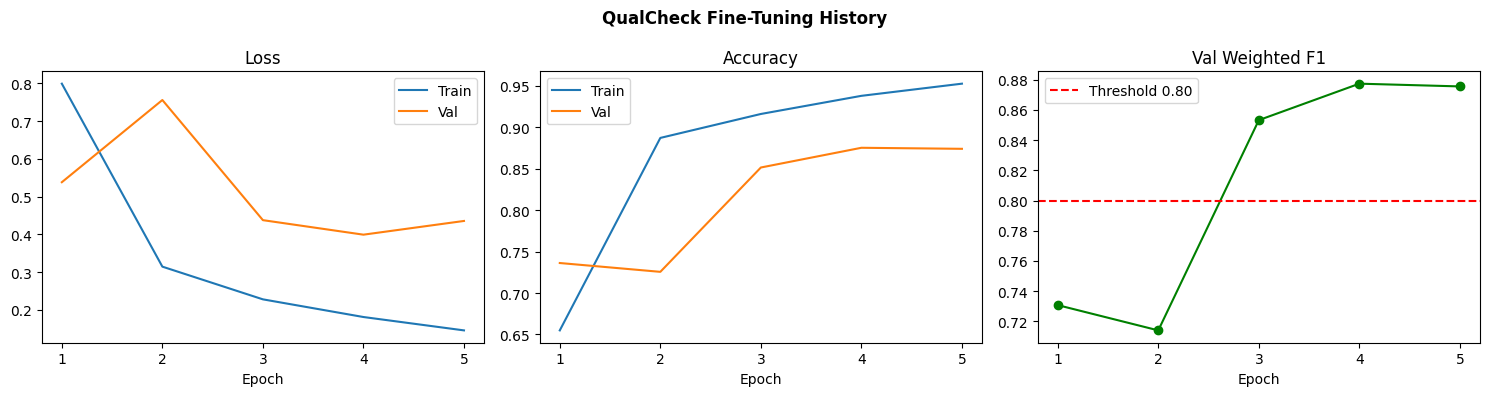

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_ran = range(1, len(history["tr_loss"]) + 1)

axes[0].plot(epochs_ran, history["tr_loss"],  label="Train")
axes[0].plot(epochs_ran, history["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(epochs_ran, history["tr_acc"],  label="Train")
axes[1].plot(epochs_ran, history["val_acc"], label="Val")
axes[1].set_title("Accuracy"); axes[1].legend()

axes[2].plot(epochs_ran, history["val_wf1"], color="green", marker="o")
axes[2].axhline(0.80, color="red", linestyle="--", label="Threshold 0.80")
axes[2].set_title("Val Weighted F1"); axes[2].legend()

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle("QualCheck Fine-Tuning History", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/training_history.png", dpi=150, bbox_inches="tight")
plt.show()


## Phase 3 – Cosine Similarity Scoring

In [18]:
# Load best checkpoint
best_state = load_file(cfg.BEST_CKPT, device=str(cfg.DEVICE))
model.load_state_dict(best_state)
model.eval()

@torch.no_grad()
def extract_cosine_sims(model, dataframe, tokenizer, cfg):
    """Returns (cos_sims, true_labels) for a split."""
    ds     = QualCheckDataset(dataframe, tokenizer, cfg.MAX_LEN_PR, cfg.MAX_LEN_R)
    loader = DataLoader(ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

    sims, labels = [], []
    for batch in tqdm(loader, desc="  Embedding", leave=False):
        cos = model.similarity(
            batch["pr_ids"].to(cfg.DEVICE),  batch["pr_mask"].to(cfg.DEVICE),
            batch["r_ids"].to(cfg.DEVICE),   batch["r_mask"].to(cfg.DEVICE)
        )
        sims.extend(cos.cpu().tolist())
        labels.extend(batch["label"].tolist())
    return np.array(sims), np.array(labels)

print("Extracting cosine similarities …")
val_sims,  val_true  = extract_cosine_sims(model, val_df,  tokenizer, cfg)
test_sims, test_true = extract_cosine_sims(model, test_df, tokenizer, cfg)

print(f"Val  sims  –  min:{val_sims.min():.4f}  max:{val_sims.max():.4f}  mean:{val_sims.mean():.4f}")
print(f"Test sims  –  min:{test_sims.min():.4f}  max:{test_sims.max():.4f}  mean:{test_sims.mean():.4f}")


Extracting cosine similarities …


  Embedding:   0%|          | 0/100 [00:00<?, ?it/s]

  Embedding:   0%|          | 0/101 [00:00<?, ?it/s]

Val  sims  –  min:-0.1813  max:0.9848  mean:0.5843
Test sims  –  min:-0.3047  max:0.9820  mean:0.5845


## Phase 3.5 – Classifier-Head Evaluation (fixes the θ-threshold mismatch)

**Why this cell exists:** the trained classification head reaches ~99.9% val accuracy because it learns from the rich feature `[p, r, |p−r|, p·r]`. Raw cosine similarity between `p` and `r` is a *different*, weaker signal that was never directly optimized to align with the labels — that's why Partially Relevant responses ended up with a *higher* mean cosine similarity (0.86) than Fully Relevant ones (0.50), making any single threshold pair (θ₁, θ₂) mathematically incapable of separating the three classes correctly.

This cell reports the classifier's own predictions (argmax over logits) as the primary evaluation, and derives a continuous "expected relevance score" from the softmax probabilities — `E[label] = 0·P(Irrelevant) + 0.5·P(Partial) + 1·P(Full)` — as a drop-in, trained-consistent replacement for the cosine-based alignment score used in the MAE/RMSE/Pearson-r metrics below. No retraining or new data is required; this reuses the already-trained checkpoint loaded above.

  Logits:   0%|          | 0/100 [00:00<?, ?it/s]

  Logits:   0%|          | 0/101 [00:00<?, ?it/s]

QualCheck – Classifier-Head Test Set Results
----------------------------------------
Overall Accuracy       : 0.8961
Precision  (weighted)  : 0.9089
Recall     (weighted)  : 0.8961
F1-Score   (macro avg) : 0.8972
Weighted F1-Score      : 0.8972

Viability threshold (≥ 0.80) : ✓ PASSED

Detailed Classification Report:
                    precision    recall  f1-score   support

        Irrelevant       1.00      0.94      0.97       536
Partially Relevant       0.95      0.79      0.86       536
    Fully Relevant       0.78      0.96      0.86       536

          accuracy                           0.90      1608
         macro avg       0.91      0.90      0.90      1608
      weighted avg       0.91      0.90      0.90      1608



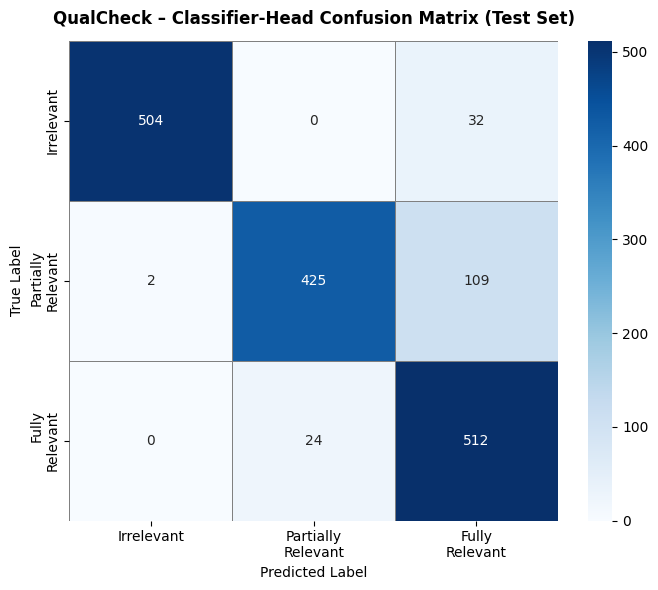


Semantic Alignment Scoring Evaluation — Classifier-Head Expected Score
----------------------------------------
MAE          : 0.0783
RMSE         : 0.1753
Pearson  r   : 0.9092  (p = 0.0000)
Threshold (r >= 0.70) : ✓ PASSED

Descriptive Statistics – Expected Score by True Class (should now be monotonic)
Class                    Mean   Median    Std
----------------------------------------------
Fully Relevant         0.9434   0.9713 0.0735
Partially Relevant     0.5962   0.5034 0.1678
Irrelevant             0.0771   0.0022 0.2005


In [19]:
# ── Classifier-head evaluation (bypasses the broken cosine threshold) ──
val_loader_eval  = DataLoader(QualCheckDataset(val_df,  tokenizer, cfg.MAX_LEN_PR, cfg.MAX_LEN_R),
                               batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader_eval = DataLoader(QualCheckDataset(test_df, tokenizer, cfg.MAX_LEN_PR, cfg.MAX_LEN_R),
                               batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

@torch.no_grad()
def extract_logits(model, loader, device):
    all_logits, all_labels = [], []
    for batch in tqdm(loader, desc="  Logits", leave=False):
        logits, _, _, _ = model(
            batch["pr_ids"].to(device),  batch["pr_mask"].to(device),
            batch["r_ids"].to(device),   batch["r_mask"].to(device)
        )
        all_logits.append(logits.cpu())
        all_labels.extend(batch["label"].tolist())
    return torch.cat(all_logits), np.array(all_labels)

val_logits_clf,  val_labels_clf  = extract_logits(model, val_loader_eval,  cfg.DEVICE)
test_logits_clf, test_labels_clf = extract_logits(model, test_loader_eval, cfg.DEVICE)

val_preds_clf  = val_logits_clf.argmax(1).numpy()
test_preds_clf = test_logits_clf.argmax(1).numpy()

# ── Classification metrics (argmax over logits, not cosine threshold) ──
clf_acc      = accuracy_score(test_labels_clf, test_preds_clf)
clf_prec     = precision_score(test_labels_clf, test_preds_clf, average="weighted", zero_division=0)
clf_rec      = recall_score(test_labels_clf, test_preds_clf, average="weighted", zero_division=0)
clf_f1_mac   = f1_score(test_labels_clf, test_preds_clf, average="macro",    zero_division=0)
clf_f1_w     = f1_score(test_labels_clf, test_preds_clf, average="weighted", zero_division=0)

print("QualCheck – Classifier-Head Test Set Results")
print("-"*40)
print(f"Overall Accuracy       : {clf_acc:.4f}")
print(f"Precision  (weighted)  : {clf_prec:.4f}")
print(f"Recall     (weighted)  : {clf_rec:.4f}")
print(f"F1-Score   (macro avg) : {clf_f1_mac:.4f}")
print(f"Weighted F1-Score      : {clf_f1_w:.4f}")
print(f"\nViability threshold (≥ 0.80) : {'✓ PASSED' if clf_f1_w >= 0.80 else '✗ FAILED'}")
print("\nDetailed Classification Report:")
print(classification_report(test_labels_clf, test_preds_clf,
                             target_names=["Irrelevant","Partially Relevant","Fully Relevant"]))

# ── Confusion matrix ──
cm_clf = confusion_matrix(test_labels_clf, test_preds_clf)
cls_names = ["Irrelevant", "Partially\nRelevant", "Fully\nRelevant"]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_clf, annot=True, fmt="d", cmap="Blues",
            xticklabels=cls_names, yticklabels=cls_names,
            linewidths=0.5, linecolor="grey")
ax.set_title("QualCheck – Classifier-Head Confusion Matrix (Test Set)", fontweight="bold", pad=12)
ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/confusion_matrix_classifier_head.png", dpi=150)
plt.show()

# ── Continuous "expected relevance score" (softmax-weighted), replaces cosine sim ──
# E[label] = 0*P(Irrelevant) + 0.5*P(Partial) + 1*P(Full)  — same [0,1] scale as norm_true below
val_probs_clf  = F.softmax(val_logits_clf,  dim=1).numpy()
test_probs_clf = F.softmax(test_logits_clf, dim=1).numpy()

val_expected_score  = val_probs_clf[:, 1]  * 0.5 + val_probs_clf[:, 2]  * 1.0
test_expected_score = test_probs_clf[:, 1] * 0.5 + test_probs_clf[:, 2] * 1.0

norm_true_clf = test_labels_clf / (cfg.NUM_LABELS - 1)
clf_mae  = np.mean(np.abs(test_expected_score - norm_true_clf))
clf_rmse = np.sqrt(np.mean((test_expected_score - norm_true_clf) ** 2))
clf_r, clf_p = pearsonr(test_expected_score, norm_true_clf)

print("\nSemantic Alignment Scoring Evaluation — Classifier-Head Expected Score")
print("-"*40)
print(f"MAE          : {clf_mae:.4f}")
print(f"RMSE         : {clf_rmse:.4f}")
print(f"Pearson  r   : {clf_r:.4f}  (p = {clf_p:.4f})")
print(f"Threshold (r >= 0.70) : {'✓ PASSED' if clf_r >= 0.70 else '✗ FAILED'}")

print("\nDescriptive Statistics – Expected Score by True Class (should now be monotonic)")
print(f"{'Class':<22} {'Mean':>6} {'Median':>8} {'Std':>6}")
print("-"*46)
for lid, lname in cfg.ID2LABEL.items():
    mask = test_labels_clf == lid
    if mask.any():
        vals = test_expected_score[mask]
        print(f"{lname:<22} {vals.mean():>6.4f} {np.median(vals):>8.4f} {vals.std():>6.4f}")


#### Post-hoc length audit — Siamese classifier head

Training-time augmentation reduces reliance on length, but the only real proof is checking the ACTUAL trained model's predictions on the untouched test set. Among test rows whose TRUE label is Fully Relevant or Irrelevant (i.e. Partial is the wrong answer), does the model still reach for "Partially Relevant" specifically on the shorter ones? If length no longer drives the shortcut, this should come back near chance (0.50).


In [20]:
# ── Post-hoc length audit: does length still predict the model's mistakes? ──
_test_len_clf = test_df[cfg.COL_RESPONSE].astype(str).str.len().values
_mask_should_not_be_partial = (test_labels_clf != cfg.LABEL2ID["Partially Relevant"])
_pred_is_partial = (test_preds_clf == cfg.LABEL2ID["Partially Relevant"]).astype(int)

_sub_len   = _test_len_clf[_mask_should_not_be_partial]
_sub_ypred = _pred_is_partial[_mask_should_not_be_partial]

if _sub_ypred.sum() > 0 and _sub_ypred.sum() < len(_sub_ypred):
    _clf_leak = cross_val_score(
        DecisionTreeClassifier(max_depth=1, random_state=cfg.SEED),
        _sub_len.reshape(-1, 1), _sub_ypred, cv=5, scoring="balanced_accuracy"
    ).mean()
    print(f"Length -> 'model predicted Partial when it shouldn't have': {_clf_leak:.4f}")
    print(f"False-Partial predictions on non-Partial truth: {_sub_ypred.sum()} / {len(_sub_ypred)}")
    print(f"{'✓ not length-driven' if _clf_leak < 0.60 else '⚠ still length-driven'}")
else:
    print("Model never (or always) predicts Partial on non-Partial truth — "
          f"count={_sub_ypred.sum()}/{len(_sub_ypred)}, can't fit a meaningful stump.")


Length -> 'model predicted Partial when it shouldn't have': 0.5000
False-Partial predictions on non-Partial truth: 24 / 1072
✓ not length-driven


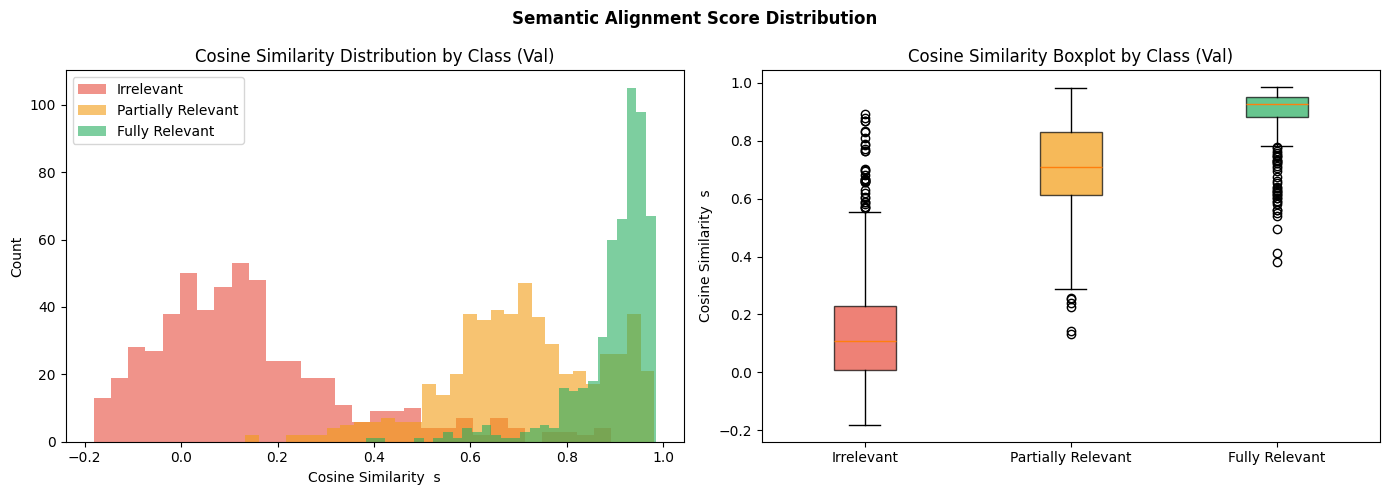

In [21]:
label_names = ["Irrelevant", "Partially Relevant", "Fully Relevant"]
colors      = ["#e74c3c",   "#f39c12",             "#27ae60"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lid in range(3):
    mask = val_true == lid
    axes[0].hist(val_sims[mask], bins=30, alpha=0.6,
                 label=label_names[lid], color=colors[lid])
axes[0].set_title("Cosine Similarity Distribution by Class (Val)")
axes[0].set_xlabel("Cosine Similarity  s"); axes[0].set_ylabel("Count")
axes[0].legend()

data_by_class = [val_sims[val_true == i] for i in range(3)]
bp = axes[1].boxplot(data_by_class, labels=label_names, patch_artist=True, notch=False)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_title("Cosine Similarity Boxplot by Class (Val)")
axes[1].set_ylabel("Cosine Similarity  s")

plt.suptitle("Semantic Alignment Score Distribution", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/similarity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## Phase 3.6 – Cross-Encoder Architecture (fixes Irrelevant ↔ Fully-Relevant confusion)

**Why:** the Siamese model above encodes `question+rubric` and `response` in two separate BERT passes, pools each to a single `[CLS]` vector, and only compares them *after* pooling (`[p, r, |p−r|, p·r]`). That pooling step throws away token-level detail — so a well-written, complete answer to the *wrong* question can look almost identical, after pooling, to a well-written, complete answer to the *right* question. That's exactly the failure mode in the confusion matrix above: 50% of true Irrelevant examples get predicted as Fully Relevant.

**Fix:** a cross-encoder — feed `[CLS] question + rubric [SEP] response [SEP]` through BERT as **one joint sequence** instead of two separate towers. Self-attention can then directly attend from response tokens to question tokens *before* any pooling happens, so a response mentioning "merge sort" when the question asks about "binary search" gets caught by direct token-level attention rather than relying on whatever survives two independent pooling operations.

**Trade-off to know about:** the bi-encoder gave the response its own 512-token budget separate from the question+rubric's 256. A cross-encoder shares one combined budget (also capped at 512, BERT's absolute limit), so long responses get truncated more aggressively here. Given question+rubric averages ~165 tokens and response ~221, most examples still fit comfortably — but the longest ~596-token responses will lose more content than they did in the bi-encoder. Worth checking whether that trade-off is worth it against the accuracy gain once you have both numbers side by side.

In [22]:
# ── Cross-Encoder Dataset: ONE joint sequence, not two separate towers ──
class QualCheckCrossDataset(Dataset):
    """
    Single joint sequence per sample:
      [CLS] question + rubric [SEP] response [SEP]
    Segment ids: 0 for question+rubric, 1 for response (handled automatically
    by the tokenizer's text_a/text_b pair encoding).

    Optional length-decorrelation augmentation (train split only, see Phase 1.6):
    this architecture sees the RAW response length even more directly than the
    two-tower Siamese model (one joint self-attention pass over the exact
    tokens present), so it is at least as exploitable via the length shortcut
    — arguably more so. Same fix as QualCheckDataset: at train time, a
    fraction of Fully Relevant / Irrelevant responses are randomly truncated
    into that SAME CRITERION's Partial-class length range before the joint
    sequence is built. Never touches the source dataframe/CSV.
    """

    def __init__(self, dataframe, tokenizer, max_len,
                 augment_length=False, augment_ratio=0.7,
                 partial_lengths_by_criterion=None,
                 label_col="label", response_col="response_text", criterion_col="criterion",
                 seed=42):
        self.df        = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

        self.augment_length = augment_length
        self.augment_ratio  = augment_ratio
        self.label_col      = label_col
        self.response_col   = response_col
        self.criterion_col  = criterion_col
        self._rng            = np.random.default_rng(seed)

        if self.augment_length:
            if partial_lengths_by_criterion is None:
                partial_mask = self.df[self.label_col] == "Partially Relevant"
                partial_lengths_by_criterion = {
                    crit: g[self.response_col].astype(str).str.len().values
                    for crit, g in self.df.loc[partial_mask].groupby(self.criterion_col)
                }
            for crit, lens in partial_lengths_by_criterion.items():
                if len(lens) == 0:
                    raise ValueError(f"augment_length=True but no Partial-class lengths "
                                      f"available for criterion {crit!r}.")
            self._partial_lengths_by_criterion = partial_lengths_by_criterion

    def __len__(self):
        return len(self.df)

    def _maybe_truncate_response(self, response_text, label, criterion):
        if not self.augment_length:
            return response_text
        if label not in ("Fully Relevant", "Irrelevant"):
            return response_text
        if self._rng.random() >= self.augment_ratio:
            return response_text
        pool = self._partial_lengths_by_criterion.get(criterion)
        if pool is None or len(pool) == 0:
            return response_text
        target_len = int(self._rng.choice(pool))
        target_len = min(target_len, len(response_text))
        if target_len <= 0:
            return response_text
        return response_text[:target_len]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text_a = row["clean_question"] + " " + row["full_rubric"]
        text_b = self._maybe_truncate_response(
            row["clean_response"], row[self.label_col], row[self.criterion_col])

        enc = self.tokenizer(
            text_a, text_b,
            add_special_tokens     = True,
            max_length             = self.max_len,
            padding                = "max_length",
            truncation              = "only_second",   # truncate the response first, keep question+rubric intact
            return_attention_mask  = True,
            return_token_type_ids  = True,
            return_tensors         = "pt"
        )

        return {
            "input_ids"      : enc["input_ids"].squeeze(0),
            "attention_mask" : enc["attention_mask"].squeeze(0),
            "token_type_ids" : enc["token_type_ids"].squeeze(0),
            "label"          : torch.tensor(row["label_id"], dtype=torch.long)
        }


In [23]:
# ── Cross-Encoder Model: single joint BERT pass, no pooled-then-compare step ──
class QualCheckCrossEncoderModel(nn.Module):
    """
    Cross-encoder: question+rubric and response attend to each other
    INSIDE BERT's self-attention, before any pooling. The [CLS] token's
    final representation already reflects token-level question<->response
    comparison, so the classifier head is much simpler than the Siamese
    model's [p, r, |p-r|, p*r] concatenation.
    """

    def __init__(self, bert_name, num_labels=3, dropout=0.3):
        super().__init__()
        self.bert       = BertModel.from_pretrained(bert_name)
        hidden          = self.bert.config.hidden_size   # 768
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, num_labels)
        )

    def forward(self, input_ids, attention_mask, token_type_ids):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask,
                         token_type_ids=token_type_ids)
        cls = self.dropout(out.last_hidden_state[:, 0, :])   # [B, 768] — already cross-attended
        logits = self.classifier(cls)
        return logits


criterion_cross = nn.CrossEntropyLoss()

def train_one_epoch_cross(model, loader, optimiser, scheduler, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for batch in tqdm(loader, desc="  Train (cross)", leave=False):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        labels         = batch["label"].to(device)

        optimiser.zero_grad()
        logits = model(input_ids, attention_mask, token_type_ids)
        loss = criterion_cross(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += labels.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate_cross(model, loader, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="  Eval (cross)", leave=False):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        labels         = batch["label"].to(device)

        logits = model(input_ids, attention_mask, token_type_ids)
        loss = criterion_cross(logits, labels)

        total_loss += loss.item() * labels.size(0)
        preds       = logits.argmax(1)
        correct    += (preds == labels).sum().item()
        n          += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / n
    acc      = correct / n
    wf1      = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    return avg_loss, acc, wf1, all_preds, all_labels


In [24]:
# ── Train the cross-encoder (same splits as the Siamese model, for a fair comparison) ──
CROSS_MAX_LEN = 512   # shared budget for question+rubric+response combined (BERT's ceiling)

cross_model = QualCheckCrossEncoderModel(cfg.BERT_MODEL, cfg.NUM_LABELS, cfg.DROPOUT).to(cfg.DEVICE)

train_ds_cross = QualCheckCrossDataset(train_df, tokenizer, CROSS_MAX_LEN,
                             augment_length=cfg.LENGTH_AUGMENT_ENABLED,
                             augment_ratio=cfg.LENGTH_AUGMENT_RATIO,
                             partial_lengths_by_criterion=_train_partial_lengths_by_criterion,
                             label_col=cfg.COL_LABEL, response_col=cfg.COL_RESPONSE,
                             criterion_col=cfg.COL_CRITERION, seed=cfg.SEED)
# val is NEVER augmented — same reasoning as the Siamese model above.
val_ds_cross   = QualCheckCrossDataset(val_df,   tokenizer, CROSS_MAX_LEN)

train_loader_cross = DataLoader(train_ds_cross, batch_size=cfg.BATCH_SIZE, shuffle=True,
                                 num_workers=0, pin_memory=True)
val_loader_cross   = DataLoader(val_ds_cross,   batch_size=cfg.BATCH_SIZE, shuffle=False,
                                 num_workers=0, pin_memory=True)

total_steps_cross  = len(train_loader_cross) * cfg.MAX_EPOCHS
warmup_steps_cross = int(total_steps_cross * cfg.WARMUP_RATIO)

optimiser_cross = AdamW(cross_model.parameters(), lr=cfg.LR, eps=1e-8, weight_decay=0.01)
scheduler_cross = get_linear_schedule_with_warmup(optimiser_cross, warmup_steps_cross, total_steps_cross)

CROSS_BEST_CKPT = f"{cfg.OUTPUT_DIR}/best_model_crossencoder.safetensors"

history_cross = {k: [] for k in ["tr_loss","tr_acc","val_loss","val_acc","val_wf1"]}
best_val_loss_cross = float("inf")
best_val_wf1_cross  = 0.0
no_improve_cross    = 0

print(f"Training cross-encoder on {cfg.DEVICE}  |  {total_steps_cross} total steps")
print("="*60)

for epoch in range(cfg.MAX_EPOCHS):
    tr_loss, tr_acc = train_one_epoch_cross(cross_model, train_loader_cross, optimiser_cross, scheduler_cross, cfg.DEVICE)
    val_loss, val_acc, val_wf1, _, _ = evaluate_cross(cross_model, val_loader_cross, cfg.DEVICE)

    history_cross["tr_loss"].append(tr_loss);  history_cross["tr_acc"].append(tr_acc)
    history_cross["val_loss"].append(val_loss); history_cross["val_acc"].append(val_acc)
    history_cross["val_wf1"].append(val_wf1)

    marker = ""
    if val_loss < best_val_loss_cross:
        best_val_loss_cross = val_loss
        best_val_wf1_cross  = val_wf1
        save_file(safe_state_dict(cross_model), CROSS_BEST_CKPT)
        marker = "  ← best saved (lowest val_loss)"
        no_improve_cross = 0
    else:
        no_improve_cross += 1

    print(f"Epoch {epoch+1}/{cfg.MAX_EPOCHS}  tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  "
          f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  val_wf1={val_wf1:.4f}{marker}")

    if no_improve_cross >= cfg.PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"\nBest Val Loss (cross)        : {best_val_loss_cross:.4f}")
print(f"Best Val Weighted-F1 (cross) : {best_val_wf1_cross:.4f}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training cross-encoder on cuda  |  2685 total steps


  Train (cross):   0%|          | 0/537 [00:00<?, ?it/s]

  Eval (cross):   0%|          | 0/100 [00:00<?, ?it/s]

...

  Eval (cross):   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 4/5  tr_loss=0.1547  tr_acc=0.9331  val_loss=0.2244  val_acc=0.9016  val_wf1=0.9010  ← best saved (lowest val_loss)


  Train (cross):   0%|          | 0/537 [00:00<?, ?it/s]

  Eval (cross):   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 5/5  tr_loss=0.1293  tr_acc=0.9480  val_loss=0.2926  val_acc=0.9035  val_wf1=0.9034

Best Val Loss (cross)        : 0.2244
Best Val Weighted-F1 (cross) : 0.9010


  Eval (cross):   0%|          | 0/101 [00:00<?, ?it/s]

QualCheck – Cross-Encoder Test Set Results
----------------------------------------
Overall Accuracy : 0.8986
Weighted F1      : 0.8976   (Siamese classifier-head was 0.8972)
Viability threshold (>= 0.80): ✓ PASSED

Detailed Classification Report:
                    precision    recall  f1-score   support

        Irrelevant       1.00      1.00      1.00       536
Partially Relevant       0.94      0.75      0.83       536
    Fully Relevant       0.79      0.95      0.86       536

          accuracy                           0.90      1608
         macro avg       0.91      0.90      0.90      1608
      weighted avg       0.91      0.90      0.90      1608



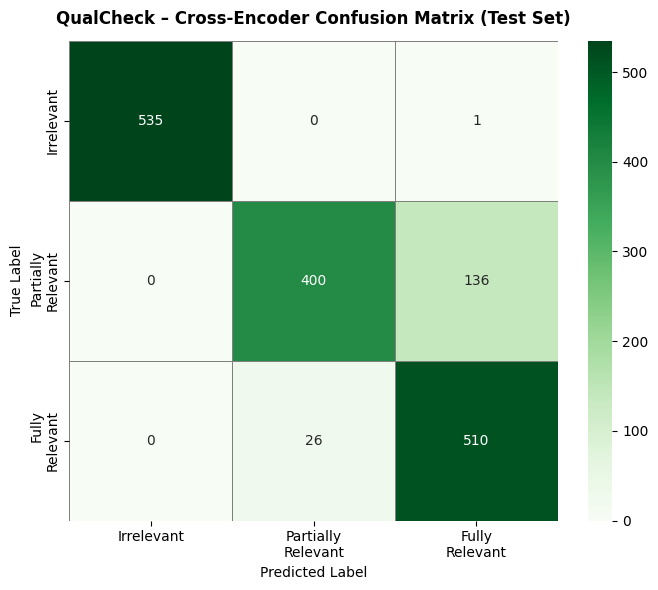


ΔWF1 vs Siamese classifier-head : +0.0004


In [25]:
# ── Cross-encoder: test-set evaluation (load best checkpoint first) ──
cross_best_state = load_file(CROSS_BEST_CKPT, device=str(cfg.DEVICE))
cross_model.load_state_dict(cross_best_state)
cross_model.eval()

test_ds_cross    = QualCheckCrossDataset(test_df, tokenizer, CROSS_MAX_LEN)
test_loader_cross = DataLoader(test_ds_cross, batch_size=cfg.BATCH_SIZE, shuffle=False,
                                num_workers=0, pin_memory=True)

test_loss_x, test_acc_x, test_wf1_x, test_preds_x, test_labels_x = evaluate_cross(
    cross_model, test_loader_cross, cfg.DEVICE
)

print("QualCheck – Cross-Encoder Test Set Results")
print("-"*40)
print(f"Overall Accuracy : {test_acc_x:.4f}")
print(f"Weighted F1      : {test_wf1_x:.4f}   (Siamese classifier-head was {clf_f1_w:.4f})")
print(f"Viability threshold (>= 0.80): {'✓ PASSED' if test_wf1_x >= 0.80 else '✗ FAILED'}")
print()
print("Detailed Classification Report:")
print(classification_report(test_labels_x, test_preds_x,
                             target_names=["Irrelevant","Partially Relevant","Fully Relevant"]))

cm_x = confusion_matrix(test_labels_x, test_preds_x)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_x, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Irrelevant","Partially\nRelevant","Fully\nRelevant"],
            yticklabels=["Irrelevant","Partially\nRelevant","Fully\nRelevant"],
            linewidths=0.5, linecolor="grey")
ax.set_title("QualCheck – Cross-Encoder Confusion Matrix (Test Set)", fontweight="bold", pad=12)
ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/confusion_matrix_crossencoder.png", dpi=150)
plt.show()

print(f"\nΔWF1 vs Siamese classifier-head : {test_wf1_x - clf_f1_w:+.4f}")
# (ΔWF1 vs BL1 is reported later in the Results Summary table, once the
#  baselines have actually been computed -- this cell runs before that.)


In [26]:
# ── Continuous "expected relevance score" for the cross-encoder ────────
# Same construction as the classifier head above: E[label] = 0*P(Irrelevant)
# + 0.5*P(Partial) + 1*P(Full), softmax over the SAME logits already
# produced by evaluate_cross's forward pass — evaluate_cross just didn't
# keep them, so this re-runs a lightweight logits-only pass (no training,
# no backward) to get them for the MAE/RMSE/Pearson-r metrics.
@torch.no_grad()
def extract_logits_cross(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    for batch in tqdm(loader, desc="  Logits (cross)", leave=False):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        logits = model(input_ids, attention_mask, token_type_ids)
        all_logits.append(logits.cpu())
        all_labels.extend(batch["label"].tolist())
    return torch.cat(all_logits), np.array(all_labels)

test_logits_x, _test_labels_x_check = extract_logits_cross(cross_model, test_loader_cross, cfg.DEVICE)
assert (np.array(test_labels_x) == _test_labels_x_check).all(), \
    "label order mismatch between evaluate_cross and extract_logits_cross — loader must not shuffle"

test_probs_x = F.softmax(test_logits_x, dim=1).numpy()
test_expected_score_x = test_probs_x[:, 1] * 0.5 + test_probs_x[:, 2] * 1.0

norm_true_x = np.array(test_labels_x) / (cfg.NUM_LABELS - 1)
cross_mae  = np.mean(np.abs(test_expected_score_x - norm_true_x))
cross_rmse = np.sqrt(np.mean((test_expected_score_x - norm_true_x) ** 2))
cross_r, cross_p = pearsonr(test_expected_score_x, norm_true_x)

print("Semantic Alignment Scoring Evaluation — Cross-Encoder Expected Score")
print("-"*40)
print(f"MAE          : {cross_mae:.4f}")
print(f"RMSE         : {cross_rmse:.4f}")
print(f"Pearson  r   : {cross_r:.4f}  (p = {cross_p:.4f})")
print(f"Threshold (r >= 0.70) : {'✓ PASSED' if cross_r >= 0.70 else '✗ FAILED'}")

print("\nDescriptive Statistics – Expected Score by True Class (should now be monotonic)")
print(f"{'Class':<22} {'Mean':>6} {'Median':>8} {'Std':>6}")
print("-"*46)
for lid, lname in cfg.ID2LABEL.items():
    mask = np.array(test_labels_x) == lid
    if mask.any():
        vals = test_expected_score_x[mask]
        print(f"{lname:<22} {vals.mean():>6.4f} {np.median(vals):>8.4f} {vals.std():>6.4f}")


  Logits (cross):   0%|          | 0/101 [00:00<?, ?it/s]

Semantic Alignment Scoring Evaluation — Cross-Encoder Expected Score
----------------------------------------
MAE          : 0.0586
RMSE         : 0.1357
Pearson  r   : 0.9460  (p = 0.0000)
Threshold (r >= 0.70) : ✓ PASSED

Descriptive Statistics – Expected Score by True Class (should now be monotonic)
Class                    Mean   Median    Std
----------------------------------------------
Fully Relevant         0.9445   0.9814 0.0874
Partially Relevant     0.6186   0.5029 0.1725
Irrelevant             0.0017   0.0004 0.0271


#### Post-hoc length audit — Cross-encoder

Same check, for the cross-encoder. This architecture sees response length even more directly (one joint self-attention pass over the literal tokens present), so if the length shortcut survived anywhere, it's most likely to show up here.


In [27]:
# ── Post-hoc length audit: cross-encoder ──────────────────────────────
_test_len_x = test_df[cfg.COL_RESPONSE].astype(str).str.len().values
_mask_should_not_be_partial_x = (np.array(test_labels_x) != cfg.LABEL2ID["Partially Relevant"])
_pred_is_partial_x = (np.array(test_preds_x) == cfg.LABEL2ID["Partially Relevant"]).astype(int)

_sub_len_x   = _test_len_x[_mask_should_not_be_partial_x]
_sub_ypred_x = _pred_is_partial_x[_mask_should_not_be_partial_x]

if _sub_ypred_x.sum() > 0 and _sub_ypred_x.sum() < len(_sub_ypred_x):
    _cross_leak = cross_val_score(
        DecisionTreeClassifier(max_depth=1, random_state=cfg.SEED),
        _sub_len_x.reshape(-1, 1), _sub_ypred_x, cv=5, scoring="balanced_accuracy"
    ).mean()
    print(f"Length -> 'model predicted Partial when it shouldn't have': {_cross_leak:.4f}")
    print(f"False-Partial predictions on non-Partial truth: {_sub_ypred_x.sum()} / {len(_sub_ypred_x)}")
    print(f"{'✓ not length-driven' if _cross_leak < 0.60 else '⚠ still length-driven'}")
else:
    print("Model never (or always) predicts Partial on non-Partial truth — "
          f"count={_sub_ypred_x.sum()}/{len(_sub_ypred_x)}, can't fit a meaningful stump.")

if 'test_acc_x' in dir() and test_acc_x > 0.97:
    print("\n⚠ Accuracy is still extremely high (>97%) even after the length fix. If the post-hoc")
    print("  audit above also comes back clean, treat this as a genuine result but sanity-check")
    print("  against question-level leakage too (GroupShuffleSplit is already in place for this,")
    print("  but worth re-confirming train/val/test share zero questions before trusting 99%+).")


Length -> 'model predicted Partial when it shouldn't have': 0.5000
False-Partial predictions on non-Partial truth: 26 / 1072
✓ not length-driven


## Phase 4 – Threshold Calibration (Grid Search)

Equation 3.3 from the thesis:

$$C(s) = \begin{cases} \text{Fully Relevant} & s \ge \theta_1 \\ \text{Partially Relevant} & \theta_2 \le s < \theta_1 \\ \text{Irrelevant} & s < \theta_2 \end{cases}$$

In [28]:
def classify(sims, theta1, theta2):
    """Apply rubric-based 3-class classification C(s)."""
    preds = np.full(len(sims), 0, dtype=int)
    preds[sims >= theta1]                              = 2  # Fully Relevant
    preds[(sims >= theta2) & (sims < theta1)]          = 1  # Partially Relevant
    # sims < theta2                                    = 0  # Irrelevant
    return preds


def grid_search_thresholds(sims, true_labels, step=0.01):
    """Exhaustive grid search - maximises (balanced_accuracy + macro-F1) / 2.

    Balanced accuracy and macro-F1 weight all three classes (Irrelevant /
    Partially Relevant / Fully Relevant) equally, regardless of how many
    examples of each land in the validation split. Plain accuracy and
    weighted-F1 let the majority class dominate the objective, which can
    pull thresholds toward whichever class happens to be over-represented
    instead of genuinely separating all three classes.
    """
    candidates = np.arange(float(sims.min()), float(sims.max()), step)
    best = dict(theta1=0.8, theta2=0.5, score=0.0, bal_acc=0.0, f1_macro=0.0)
    records = []

    for t1 in candidates:
        for t2 in candidates:
            if t2 >= t1:
                continue
            preds   = classify(sims, t1, t2)
            bal_acc = balanced_accuracy_score(true_labels, preds)
            f1_mac  = f1_score(true_labels, preds, average="macro", zero_division=0)
            combined = (bal_acc + f1_mac) / 2.0
            records.append({"theta1": round(t1,4), "theta2": round(t2,4),
                             "balanced_accuracy": bal_acc, "macro_f1": f1_mac,
                             "combined": combined})
            if combined > best["score"]:
                best.update(theta1=t1, theta2=t2, score=combined,
                            bal_acc=bal_acc, f1_macro=f1_mac)

    return best, pd.DataFrame(records)


print("Running grid search on validation set …  (step = 0.01)")
best_thresh, thresh_df = grid_search_thresholds(val_sims, val_true, cfg.THRESH_STEP)

θ1 = best_thresh["theta1"]
θ2 = best_thresh["theta2"]

print(f"\n{'='*50}")
print(f" Optimal thresholds")
print(f"  θ₁  (Fully Relevant   boundary) : {θ1:.4f}")
print(f"  θ₂  (Irrelevant       boundary) : {θ2:.4f}")
print(f"  Combined score (bal_acc+macroF1)/2 : {best_thresh['score']:.4f}")
print(f"  Val balanced accuracy           : {best_thresh['bal_acc']:.4f}")
print(f"  Val macro-F1                    : {best_thresh['f1_macro']:.4f}")
print(f"{'='*50}")
print(f"\nClassification rule:")
print(f"  s ≥ {θ1:.4f}                 → Fully Relevant")
print(f"  {θ2:.4f} ≤ s < {θ1:.4f}  → Partially Relevant")
print(f"  s <  {θ2:.4f}                 → Irrelevant")

print("\nTop 10 threshold pairs:")
print(thresh_df.nlargest(10, "combined")[["theta1","theta2","balanced_accuracy","macro_f1","combined"]]      .to_string(index=False))


Running grid search on validation set …  (step = 0.01)

 Optimal thresholds
  θ₁  (Fully Relevant   boundary) : 0.8287
  θ₂  (Irrelevant       boundary) : 0.4887
  Combined score (bal_acc+macroF1)/2 : 0.8145
  Val balanced accuracy           : 0.8158
  Val macro-F1                    : 0.8133

Classification rule:
  s ≥ 0.8287                 → Fully Relevant
  0.4887 ≤ s < 0.8287  → Partially Relevant
  s <  0.4887                 → Irrelevant

Top 10 threshold pairs:
 theta1  theta2  balanced_accuracy  macro_f1  combined
 0.8287  0.4887           0.815789  0.813274  0.814532
 0.7887  0.4887           0.817043  0.811667  0.814355
 0.7887  0.3587           0.814536  0.813621  0.814078
 0.8287  0.4787           0.815163  0.812981  0.814072
 0.8287  0.3587           0.813283  0.814701  0.813992
 0.7887  0.4787           0.816416  0.811409  0.813913
 0.8287  0.4687           0.814536  0.812821  0.813679
 0.8187  0.4887           0.815163  0.812076  0.813619
 0.7887  0.4687           0.815

## Phase 5 – System Evaluation

### Classification Performance (Test Set)

In [29]:
qc_preds = classify(test_sims, θ1, θ2)

acc    = accuracy_score(test_true, qc_preds)
prec   = precision_score(test_true, qc_preds, average="weighted", zero_division=0)
rec    = recall_score(test_true, qc_preds, average="weighted", zero_division=0)
f1_mac = f1_score(test_true, qc_preds, average="macro",    zero_division=0)
f1_w   = f1_score(test_true, qc_preds, average="weighted", zero_division=0)

print("QualCheck – Test Set Results")
print("-"*40)
print(f"Overall Accuracy       : {acc:.4f}")
print(f"Precision  (weighted)  : {prec:.4f}")
print(f"Recall     (weighted)  : {rec:.4f}")
print(f"F1-Score   (macro avg) : {f1_mac:.4f}")
print(f"Weighted F1-Score      : {f1_w:.4f}")
viability = "✓ PASSED" if f1_w >= 0.80 else "✗ FAILED"
print(f"\nViability threshold (≥ 0.80) : {viability}")

print("\nDetailed Classification Report:")
print(classification_report(test_true, qc_preds,
      target_names=["Irrelevant","Partially Relevant","Fully Relevant"]))


QualCheck – Test Set Results
----------------------------------------
Overall Accuracy       : 0.8408
Precision  (weighted)  : 0.8429
Recall     (weighted)  : 0.8408
F1-Score   (macro avg) : 0.8363
Weighted F1-Score      : 0.8363

Viability threshold (≥ 0.80) : ✓ PASSED

Detailed Classification Report:
                    precision    recall  f1-score   support

        Irrelevant       0.93      0.97      0.95       536
Partially Relevant       0.83      0.65      0.73       536
    Fully Relevant       0.77      0.90      0.83       536

          accuracy                           0.84      1608
         macro avg       0.84      0.84      0.84      1608
      weighted avg       0.84      0.84      0.84      1608



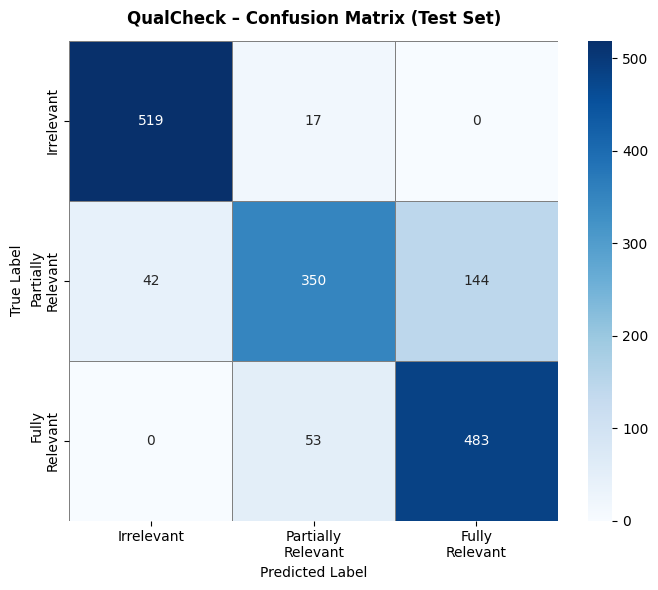

In [30]:
cm = confusion_matrix(test_true, qc_preds)
cls_names = ["Irrelevant", "Partially\nRelevant", "Fully\nRelevant"]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=cls_names, yticklabels=cls_names,
            linewidths=0.5, linecolor="grey")
ax.set_title("QualCheck – Confusion Matrix (Test Set)", fontweight="bold", pad=12)
ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


### Semantic Alignment Scoring Quality (MAE, RMSE, Pearson r)

In [31]:
# Normalise ordinal labels to [0, 1]  :  0→0.0, 1→0.5, 2→1.0
norm_true = test_true / (cfg.NUM_LABELS - 1)

mae  = np.mean(np.abs(test_sims - norm_true))
rmse = np.sqrt(np.mean((test_sims - norm_true) ** 2))
r, p_r = pearsonr(test_sims, norm_true)

print("Semantic Alignment Scoring Evaluation")
print("-"*40)
print(f"MAE          : {mae:.4f}")
print(f"RMSE         : {rmse:.4f}")
print(f"Pearson  r   : {r:.4f}  (p = {p_r:.4f})")
pearson_ok = "✓ PASSED" if r >= 0.70 else "✗ FAILED"
print(f"Threshold (r ≥ 0.70) : {pearson_ok}")


Semantic Alignment Scoring Evaluation
----------------------------------------
MAE          : 0.1620
RMSE         : 0.2099
Pearson  r   : 0.8825  (p = 0.0000)
Threshold (r ≥ 0.70) : ✓ PASSED


### Baseline Comparisons

In [32]:
# ── Baseline 1 : TF-IDF Cosine Similarity ─────────────────────────
print("--- Baseline 1: TF-IDF Cosine Similarity ---")

tfidf_all = (list(train_df["tfidf_question"] + " " + train_df["tfidf_rubric"]) +
             list(train_df["tfidf_response"]))
tfidf_vec = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2))
tfidf_vec.fit(tfidf_all)

def tfidf_sims_for(df_split):
    pr_vecs = tfidf_vec.transform(df_split["tfidf_question"] + " " + df_split["tfidf_rubric"])
    r_vecs  = tfidf_vec.transform(df_split["tfidf_response"])
    return np.array([tfidf_cos(pr_vecs[i], r_vecs[i])[0, 0]
                     for i in range(len(df_split))])

bl1_val_sims  = tfidf_sims_for(val_df)
bl1_test_sims = tfidf_sims_for(test_df)

bl1_best, _   = grid_search_thresholds(bl1_val_sims, val_true, 0.01)
bl1_preds     = classify(bl1_test_sims, bl1_best["theta1"], bl1_best["theta2"])
bl1_acc       = accuracy_score(test_true, bl1_preds)
bl1_wf1       = f1_score(test_true, bl1_preds, average="weighted", zero_division=0)
bl1_r, _      = pearsonr(bl1_test_sims, norm_true)
bl1_mae       = np.mean(np.abs(bl1_test_sims - norm_true))

print(f"  Accuracy     : {bl1_acc:.4f}")
print(f"  Weighted F1  : {bl1_wf1:.4f}")
print(f"  Pearson r    : {bl1_r:.4f}")
print(f"  MAE          : {bl1_mae:.4f}")


--- Baseline 1: TF-IDF Cosine Similarity ---
  Accuracy     : 0.7046
  Weighted F1  : 0.7008
  Pearson r    : 0.7892
  MAE          : 0.2060


In [33]:
# ── Baseline 2 : BERT Cosine Similarity without rubric ─────────────
print("--- Baseline 2: BERT Cosine Similarity (no rubric) ---")

@torch.no_grad()
def bert_only_sims(model, dataframe, tokenizer, cfg):
    """Encode question-only (no rubric) vs response."""
    sims = []
    model.eval()
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe),
                       desc="  BL2", leave=False):
        # transformers 5.x removed encode_plus() — use the callable
        # tokenizer() interface instead (same replacement as QualCheckDataset).
        q_enc = tokenizer(
            row["clean_question"],
            add_special_tokens=True, max_length=cfg.MAX_LEN_PR,
            padding="max_length", truncation=True,
            return_attention_mask=True, return_tensors="pt")
        r_enc = tokenizer(
            row["clean_response"],
            add_special_tokens=True, max_length=cfg.MAX_LEN_R,
            padding="max_length", truncation=True,
            return_attention_mask=True, return_tensors="pt")
        cos = model.similarity(
            q_enc["input_ids"].to(cfg.DEVICE), q_enc["attention_mask"].to(cfg.DEVICE),
            r_enc["input_ids"].to(cfg.DEVICE), r_enc["attention_mask"].to(cfg.DEVICE))
        sims.append(cos.item())
    return np.array(sims)

bl2_val_sims  = bert_only_sims(model, val_df,  tokenizer, cfg)
bl2_test_sims = bert_only_sims(model, test_df, tokenizer, cfg)

bl2_best, _   = grid_search_thresholds(bl2_val_sims, val_true, 0.01)
bl2_preds     = classify(bl2_test_sims, bl2_best["theta1"], bl2_best["theta2"])
bl2_acc       = accuracy_score(test_true, bl2_preds)
bl2_wf1       = f1_score(test_true, bl2_preds, average="weighted", zero_division=0)
bl2_r, _      = pearsonr(bl2_test_sims, norm_true)
bl2_mae       = np.mean(np.abs(bl2_test_sims - norm_true))

print(f"  Accuracy     : {bl2_acc:.4f}")
print(f"  Weighted F1  : {bl2_wf1:.4f}")
print(f"  Pearson r    : {bl2_r:.4f}")
print(f"  MAE          : {bl2_mae:.4f}")


--- Baseline 2: BERT Cosine Similarity (no rubric) ---


  BL2:   0%|          | 0/1596 [00:00<?, ?it/s]

  BL2:   0%|          | 0/1608 [00:00<?, ?it/s]

  Accuracy     : 0.8097
  Weighted F1  : 0.8051
  Pearson r    : 0.8708
  MAE          : 0.1716


Results Summary
                              System  Accuracy  Weighted F1  Pearson r      MAE  ΔMAE vs BL1  ΔWF1 vs BL1
                        BL1 – TF-IDF  0.704602     0.700782   0.789186 0.205974       0.0000       0.0000
              BL2 – BERT (no rubric)  0.809701     0.805081   0.870760 0.171580      -0.0344       0.1043
QualCheck (cosine-threshold, Eq 3.3)  0.840796     0.836348   0.882466 0.162017      -0.0440       0.1356
         QualCheck (classifier head)  0.896144     0.897181   0.909178 0.078298      -0.1277       0.1964
           QualCheck (cross-encoder)  0.898632     0.897627   0.945955 0.058581      -0.1474       0.1968


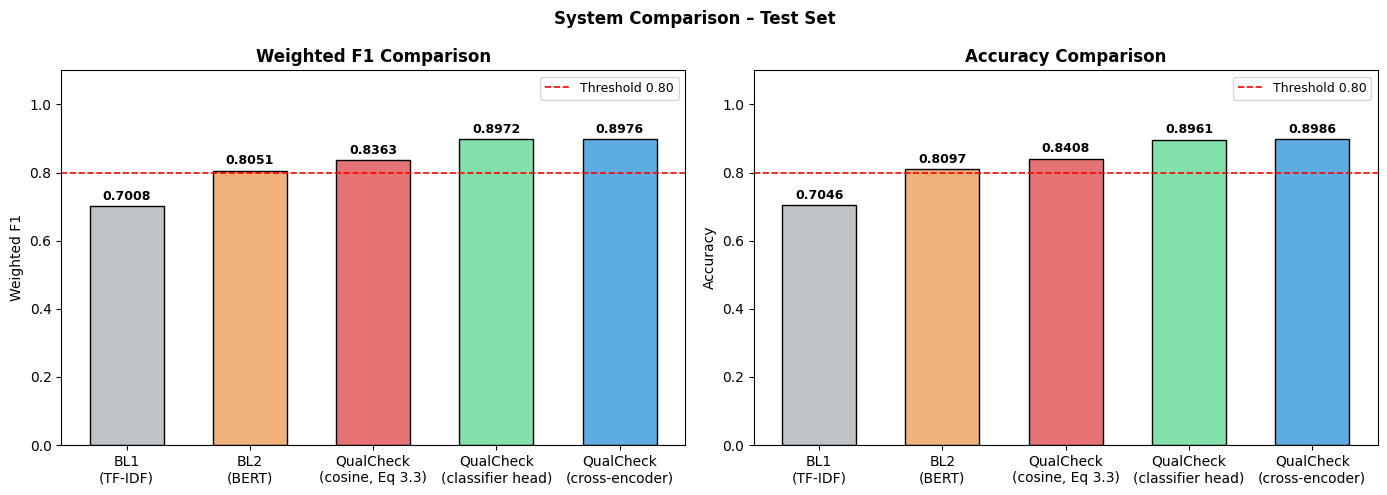

In [34]:
results = pd.DataFrame({
    "System"       : ["BL1 – TF-IDF", "BL2 – BERT (no rubric)", "QualCheck (cosine-threshold, Eq 3.3)",
                      "QualCheck (classifier head)", "QualCheck (cross-encoder)"],
    "Accuracy"     : [bl1_acc,  bl2_acc,  acc,      clf_acc,  test_acc_x],
    "Weighted F1"  : [bl1_wf1,  bl2_wf1,  f1_w,     clf_f1_w, test_wf1_x],
    "Pearson r"    : [bl1_r,    bl2_r,    r,        clf_r,    cross_r],
    "MAE"          : [bl1_mae,  bl2_mae,  mae,      clf_mae,  cross_mae],
    "ΔMAE vs BL1"  : [0.0, round(bl2_mae - bl1_mae, 4), round(mae - bl1_mae, 4), round(clf_mae - bl1_mae, 4), round(cross_mae - bl1_mae, 4)],
    "ΔWF1 vs BL1"  : [0.0, round(bl2_wf1 - bl1_wf1, 4), round(f1_w - bl1_wf1, 4), round(clf_f1_w - bl1_wf1, 4),
                      round(test_wf1_x - bl1_wf1, 4)],
})
results.to_csv(f"{cfg.OUTPUT_DIR}/results_summary.csv", index=False)

print("Results Summary")
print(results.to_string(index=False))

# ── Comparison bar chart ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sys_labels = ["BL1\n(TF-IDF)", "BL2\n(BERT)", "QualCheck\n(cosine, Eq 3.3)", "QualCheck\n(classifier head)", "QualCheck\n(cross-encoder)"]
bar_colors = ["#bdc3c7", "#f0b27a", "#e57373", "#82e0aa", "#5dade2"]

for ax, metric in zip(axes, ["Weighted F1", "Accuracy"]):
    vals = results[metric].tolist()
    bars = ax.bar(sys_labels, vals, color=bar_colors, edgecolor="black", width=0.6)
    ax.set_ylim(0, 1.1); ax.set_ylabel(metric)
    ax.set_title(f"{metric} Comparison", fontweight="bold")
    ax.axhline(0.80, color="red", linestyle="--", lw=1.2, label="Threshold 0.80")
    ax.legend(fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{v:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("System Comparison – Test Set", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/system_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### Statistical Tests

In [35]:
print("1. Score-Level Agreement (Pearson r)")
print(f"   QualCheck :  r = {r:.4f},  p = {p_r:.4f}")
print(f"   Target r ≥ 0.70 : {'✓ PASSED' if r >= 0.70 else '✗ FAILED'}\n")

# ── Descriptive statistics by class ───────────────────────────────
print("2. Descriptive Statistics – Cosine Similarity by Relevance Class")
print(f"{'Class':<22} {'Mean':>6} {'Median':>8} {'Std':>6} {'IQR':>6}")
print("-" * 52)
for lid, lname in cfg.ID2LABEL.items():
    mask = test_true == lid
    if mask.any():
        s = test_sims[mask]
        iqr = np.percentile(s, 75) - np.percentile(s, 25)
        print(f"{lname:<22} {s.mean():>6.4f} {np.median(s):>8.4f} {s.std():>6.4f} {iqr:>6.4f}")

# ── One-Way ANOVA (if output_type column exists) ───────────────────
type_col = cfg.COL_OUTPUT_TYPE
if type_col and type_col in test_df.columns:
    print(f"\n3. One-Way ANOVA – Cross-Output-Type Consistency")
    groups     = test_df[type_col].unique()
    group_sims = [test_sims[test_df[type_col].values == g] for g in groups]
    F, p_anova = f_oneway(*group_sims)
    print(f"   F = {F:.4f},  p = {p_anova:.4f}")

    if p_anova > 0.05:
        print("   Non-significant (p > 0.05): consistent across output types ✓")
    else:
        print("   Significant (p ≤ 0.05): Tukey HSD post-hoc analysis:")
        all_s = np.concatenate(group_sims)
        all_g = np.concatenate([[g]*len(s) for g, s in zip(groups, group_sims)])
        print(pairwise_tukeyhsd(all_s, all_g, alpha=0.05))
else:
    print("\n3. One-Way ANOVA : skipped (no output_type column found)")
    print("   Add a column named 'output_type' with values ")
    print("   ('short_answer', 'essay', 'code_report') to enable this test.")


1. Score-Level Agreement (Pearson r)
   QualCheck :  r = 0.8825,  p = 0.0000
   Target r ≥ 0.70 : ✓ PASSED

2. Descriptive Statistics – Cosine Similarity by Relevance Class
Class                    Mean   Median    Std    IQR
----------------------------------------------------
Fully Relevant         0.9110   0.9284 0.0644 0.0574
Partially Relevant     0.7244   0.7244 0.1561 0.2036
Irrelevant             0.1181   0.0850 0.1774 0.2184

3. One-Way ANOVA : skipped (no output_type column found)
   Add a column named 'output_type' with values 
   ('short_answer', 'essay', 'code_report') to enable this test.


## Save Final Model & Predictions

In [ ]:
# ── Pick whichever architecture performs better on VALIDATION, not test ──
# Choosing the architecture by test-set score turns the test set into a second
# validation set for model selection, which optimistically biases the number
# you then report as your held-out result. best_val_wf1 (Siamese) and
# best_val_wf1_cross (cross-encoder) were both recorded during training and
# never touched by anything in the test split, so use those for the decision;
# test metrics are still what gets reported for the winner, but only after
# the pick is already made.
if best_val_wf1_cross > best_val_wf1:
    winner_name, winner_model, winner_acc, winner_wf1 = "cross-encoder", cross_model, test_acc_x, test_wf1_x
else:
    winner_name, winner_model, winner_acc, winner_wf1 = "classifier head (Siamese)", model, clf_acc, clf_f1_w

# ── Save full checkpoint (model weights + thresholds) ──────────────
# safetensors only stores tensors, so weights and metadata are saved
# as two companion files: FINAL_MODEL (.safetensors) + FINAL_META (.json)
save_file(safe_state_dict(winner_model), cfg.FINAL_MODEL)

final_meta = {
    "theta1"        : float(θ1),
    "theta2"        : float(θ2),
    "bert_model"    : cfg.BERT_MODEL,
    "max_len_pr"    : cfg.MAX_LEN_PR,
    "max_len_r"     : cfg.MAX_LEN_R,
    "label_map"     : cfg.LABEL2ID,
    "primary_eval"  : winner_name,   # cosine-threshold (Eq 3.3) kept only for comparison — see Phase 3.5
}
with open(cfg.FINAL_META, "w") as f:
    json.dump(final_meta, f, indent=2)

# ── Save test predictions (winning architecture is the primary prediction column) ──
out_df = test_df[[cfg.COL_QUESTION, cfg.COL_RUBRIC, cfg.COL_RESPONSE,
                  cfg.COL_LABEL]].copy()
out_df["cosine_similarity"]        = test_sims
out_df["predicted_label_cosine"]   = [cfg.ID2LABEL[p] for p in qc_preds]
out_df["expected_score_clf"]       = test_expected_score
out_df["predicted_label_clf"]      = [cfg.ID2LABEL[p] for p in test_preds_clf]
out_df["correct_clf"]              = (test_labels_clf == test_preds_clf)
out_df["predicted_label_crossenc"] = [cfg.ID2LABEL[p] for p in test_preds_x]
out_df["correct_crossenc"]         = (np.array(test_labels_x) == np.array(test_preds_x))
out_df.to_csv(f"{cfg.OUTPUT_DIR}/test_predictions.csv", index=False)

# ── Print final summary ───────────────────────────────────────────
print("="*60)
print(f" QUALCHECK – FINAL RESULTS  (primary: {winner_name})")
print("="*60)
print(f" Accuracy       : {winner_acc:.4f}")
print(f" Weighted F1    : {winner_wf1:.4f}  ({'✓' if winner_wf1>=0.80 else '✗'} viability ≥ 0.80)")
print("-"*60)
print(" Architecture comparison:")
print(f"   Siamese (classifier head) : Acc={clf_acc:.4f}  WF1={clf_f1_w:.4f}")
print(f"   Cross-encoder             : Acc={test_acc_x:.4f}  WF1={test_wf1_x:.4f}")
print(f"   Δ (cross-encoder - Siamese) WF1 : {test_wf1_x - clf_f1_w:+.4f}")
print("-"*60)
print(f" ΔWF1 vs BL1 (TF-IDF)        : {winner_wf1 - bl1_wf1:+.4f}")
print(f" ΔWF1 vs BL2 (BERT-no-rubric): {winner_wf1 - bl2_wf1:+.4f}")
print("-"*60)
print(f" [Reference, Eq 3.3 cosine-threshold] θ₁={θ1:.4f} θ₂={θ2:.4f}  "
      f"Acc={acc:.4f}  WF1={f1_w:.4f}  r={r:.4f}")
print("="*60)

print("\nSaved files:")
for f in [cfg.BEST_CKPT, CROSS_BEST_CKPT, cfg.FINAL_MODEL, cfg.FINAL_META,
          f"{cfg.OUTPUT_DIR}/test_predictions.csv",
          f"{cfg.OUTPUT_DIR}/results_summary.csv",
          f"{cfg.OUTPUT_DIR}/training_history.png",
          f"{cfg.OUTPUT_DIR}/similarity_distribution.png",
          f"{cfg.OUTPUT_DIR}/confusion_matrix.png",
          f"{cfg.OUTPUT_DIR}/confusion_matrix_classifier_head.png",
          f"{cfg.OUTPUT_DIR}/confusion_matrix_crossencoder.png",
          f"{cfg.OUTPUT_DIR}/system_comparison.png"]:
    print(f"  {f}")
print("\n✓ QualCheck pipeline complete!")


 QUALCHECK – FINAL RESULTS  (primary: cross-encoder)
 Accuracy       : 0.8986
 Weighted F1    : 0.8976  (✓ viability ≥ 0.80)
------------------------------------------------------------
 Architecture comparison:
   Siamese (classifier head) : Acc=0.8961  WF1=0.8972
   Cross-encoder             : Acc=0.8986  WF1=0.8976
   Δ (cross-encoder - Siamese) WF1 : +0.0004
------------------------------------------------------------
 ΔWF1 vs BL1 (TF-IDF)        : +0.1968
 ΔWF1 vs BL2 (BERT-no-rubric): +0.0925
------------------------------------------------------------
 [Reference, Eq 3.3 cosine-threshold] θ₁=0.8287 θ₂=0.4887  Acc=0.8408  WF1=0.8363  r=0.8825

Saved files:
  codereport_bert/best_model.safetensors
  codereport_bert/best_model_crossencoder.safetensors
  codereport_bert/qualcheck_final.safetensors
  codereport_bert/qualcheck_final_meta.json
  codereport_bert/test_predictions.csv
  codereport_bert/results_summary.csv
  codereport_bert/training_history.png
  codereport_bert/similarity